## Ash Kuinkel ~ cosc102 assingment 1

### Brief Overview: 
This program is crafted in two seperate sections to answer the two questions as provided in the task description :

1) **Predator-Prey Population Dynamics** - We are given the relationship between populations of prey (rabbit) and predator
(fox) species (i.e. as predators increase, prey decrease & vice versa), and it is explicitly modelled through differential
equations. For this task, simplicity is prioritised & we are provided the required equations. Under some assumptions; foxes
shall only eat rabbits, unlimited population growth of both species, no external influences, & given constant values (c,d,f,g)
representative of predation/reproduction rates, we need to model the population of our prey & predator in a visual manner, with the help of python/matplotlib/numpys etc. 
### ** FINISH OFF THIS DESCRIPTION FOR Q1 ** 


# Question 1 - Predator-Prey Population Dynamics 

### <u>Imports/Initialisations</u>

We first begin our program by importing the required libraries/modules. Matplotlib is a library whose main purpose is to help us in crafting visualisations in python such as histograms, bar charts, scatter plots, line graphs etc. This is the only one we really need for the first part of this assingment, i.e. question 1. More specifically, we are using the pyplot module which helps us in creating and customising our figure/axes with the methods provided. The reason we've imported it saying **import as plt** is so that we don't have to repeat matplotlib.pyplot every time we want to call a method. Instead we can just refer to it as **plt**. This is reflected in the later parts of the code.

In [107]:
# imports:
import matplotlib.pyplot as plt;

Like solving a problem in any other domain, we follow the same procedure here. Our first step towards making an effort to tackle the problem is always noting the known/gathered information we have at our disposal. This includes the initial values we are given for the populations and the constants. Note that the variable isn't called initial_pop_foxes or initial_pop_rabbits as it wouldn't be refelctive of the variable at all states of the program.

In [108]:
# Rather than having to create 4 different lines for the constant, we can declare them like this:
c,d,f,g = 0.000005,0.3,0.5,0.00001 # This is known as tuple unpacking
pop_foxes = 35000
pop_rabbits = 70000

From our content, i.e. jupyter notebooks from the lectures, we know that to plot the graph of our population models, we should have a list of int/float values that we wish to plot. Hence, we need to begin by initialising the lists, one for the foxes & one for the rabbits, as such:

In [109]:
foxes_sequence_terms = [35000]
rabbits_sequence_terms = [70000]

Note that in the initialisation of the lists above, we first put the initial values into the lists aswell. This is an important point in our discussion here. Say we didn't initialise the lists to e.g. 35,000 & 70,000, it would cause a problem as the first value wouldn't be the initial values of the populations but would rather be the populations after the first time period.

Note that I have named the variables to be foxes/rabbits_sequence_terms. This is actually the correct mathematical name for the model we have been provided in the task description (recursive sequence).

### <u>Core Sequence Logic</u>

We now move onto the chunk of our logic here which ensures that we are using the recursive model provided in the task description to generate 20 points (which are stored in the list fox/rabbit_sequence_terms) for the respective populations and this is the entire dataset required for this problem. Note that this is implemented as a resuable function with adequate documentation through the use of docstrings, as required by the quality of solution part in the marking rubric:

In [110]:
def predator_prey_data_generator(c:float,d:float,f:float,g:float,pop_foxes:float,pop_rabbits:float,time_step:int) -> None:
    '''
    Outputs required dataset for population of prey & predators after 20 time-steps w/ provided model.
    
    Args:
      c (float) : Constant value representing either reproduction or predation rate.
      d (float) : Constant value representing either reproduction or predation rate.
      f (float) : Constant value representing either reproduction or predation rate.
      g (float) : Constant value representing either reproduction or predation rate.
      pop_foxes (float) : Population of foxes at any given time.
      pop_rabbits (float) : Population of rabbits at any given time.
      time_step (int) : Determines over how much time, the model iterates toC. 
    
    Returns:
      (None) : Appends required values to arrays initialised previously.
    '''
    i = 0 # initialise var i to keep track of the amout of times we have iterated through the sequence
    while (i < time_step):
        curr_fox_pop = pop_foxes
        curr_rabbit_pop = pop_rabbits
        
        #Model for population of foxes as provided in the question description:
        pop_foxes = (((c * curr_rabbit_pop) - d) * curr_fox_pop) + curr_fox_pop 
        foxes_sequence_terms.append(pop_foxes) #add term to fox population arr
        
        #Model for population of rabbits as provided in the question description:
        pop_rabbits = ((f - (g * curr_fox_pop)) * curr_rabbit_pop) + curr_rabbit_pop
        rabbits_sequence_terms.append(pop_rabbits) # add term to rabbit population arr
        
        i+=1 # incrementing our variable i with short hand python syntax, i.e. i+=1 instead of i = i + 1

A very important mistake I first made here at first was initialising the models to just:

```python 
pop_foxes = (((c * pop_rabbits) - d) * fox_pop) + fox_pop
pop_rabbits = ((f - (g * pop_foxes)) * pop_rabbits) + pop_rabbits
```

Notice that when we work out pop_foxes, everything would be fine and we would get the intended
value. However, once we pass in that pop_foxes value to the pop_rabbits, we're actually passing the 
updated pop_foxes value. This led me to getting the wrong graph points at first. The solution for this 
problem was to initialise 2 variables to hold the current fox/rabbit population and pass those so that
the updated pop_foxes isn't passed into pop_rabbits. This is made evident within our function, through the two lines:

```python
curr_fox_pop = pop_foxes
curr_rabbit_pop = pop_rabbits
```


*We can now verify that we have populated our lists with the appropriate values, as such:*

In [111]:
#calling our function with the initialised values as such:
predator_prey_data_generator(c,d,f,g,pop_foxes,pop_rabbits,20) 

In [112]:
print(foxes_sequence_terms)

[35000, 36750.0, 40516.875, 46830.67027734375, 56152.703760730394, 68218.52160635527, 80715.90648486368, 88397.24599090994, 86080.05152379734, 74774.30367521863, 60403.23812185969, 47180.90226806577, 36454.88934746249, 28241.98161144092, 22165.15434625838, 17804.98750911231, 14814.4117846488, 12955.893168746981, 12126.221370570143, 12409.632637881228, 14219.514014718696]


In [113]:
print(rabbits_sequence_terms)

[70000, 80500.0, 91166.25, 99811.6594453125, 102975.02003478922, 96639.27210449587, 79033.02543591382, 54757.31525086, 33732.01421596924, 21561.48610683289, 16219.778061836034, 14532.395927226073, 14942.078371206204, 16965.99942037496, 20657.46469406297, 26407.438107631562, 34909.316104906975, 47192.36431837482, 64674.35417266772, 89168.97590203732, 122687.9215166523]


So this concludes the core logic function of the first question, and we are now able to continue and plot these points we've managed to gather!

### <u>Plotting Logic</u>

*Note that attempting to create a function whose params would be highly specific, e.g. x_label, y_label is very much a tedious task, and defeats the point of being able to use the methods available. Hence, there is no need of a function for our plotting logic. Also the entire plotting logic could've been in one cell, but explanations were provided for the blocks of code, hence why are split into different cells (& why we had to prevent displaying plot until all changes took place).*

Initialise the structural figure containing just a single plot axes & plot the points we managed to gather within the lists *fox_sequence_terms* and *rabbits_sequence_terms* by doing as follows:

In [114]:
fig,ax = plt.subplots();

# plotting fox population, w/label foxes for  legend and colour red as required by task:
ax.plot(foxes_sequence_terms,'r',label='Foxes') 
# plotting rabbit population, w/label rabbits for  legend and colour green as required by task:
ax.plot(rabbits_sequence_terms,'g',label='Rabbits')

plt.close(fig) # Don't display until we make all changes, else it wont be truly representative of the plot we have made..

Including the legend with the loc to best, i.e. we let it automatically decide where the best position for the legend is within our graph, & also setting the title of the graph (in bold as required):

In [115]:
ax.legend(loc='best',fontsize='x-small')

ax.set_title("Predator-Prey populations over time",weight='bold')

Text(0.5, 1.0, 'Predator-Prey populations over time')

Formatting the y axis of the graph to include label, and match the intervals as shown in the example plot within task description:

In [116]:
ax.set_ylabel("Population")
ax.set_yticks([0,20000,40000,60000,80000,100000,120000])

Formatting x axis of graph to include label, match intervals shown in example (i.e. 20) 

In [117]:
ax.set_xlabel("Time Step");
x_label_steps = list(range(21))
ax.set_xticks(x_label_steps)
ax.set(xlim=(0,20)) # configure graph to display from 0-20 label, no other extra space needed..

[(0.0, 20.0)]

Configuring colour of the labels, remove the label marks that would otherwise be present, and add faint grid (configured via alpha value) to try and match the example plot exactly:

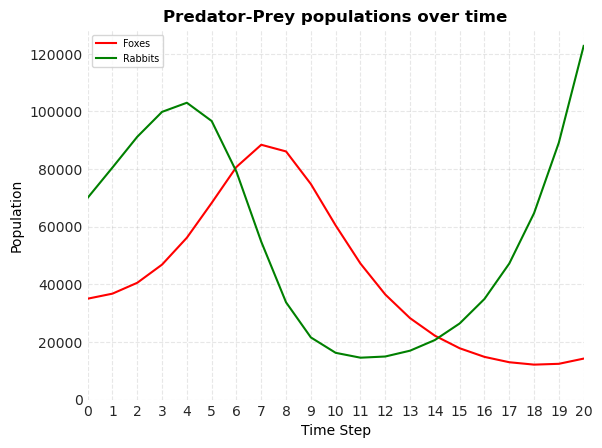

In [118]:
ax.tick_params(length=0,axis='both',labelcolor=(38/255,38/255,38/255)) #Normalisation with the /255

#Disable the tick marks on all the axes:
for spine in ax.spines.values(): 
    spine.set_visible(False)

ax.grid(alpha=0.3,linestyle='--')

display(fig) # Displaying the final plot

Our final step is to now save the plot to a file as required by the assessment task:

In [119]:
#saving figure to file:
fig.savefig("AKuinkelAT1Q1-Predator-Prey-model.png")

# Question 2 - Predator-Prey Population Dynamics 

### <u>Imports/Initialisations</u>

The core logic for question 2, just explain everything and put it into this note book then that should be it....

[(-12.0, 12.0)]

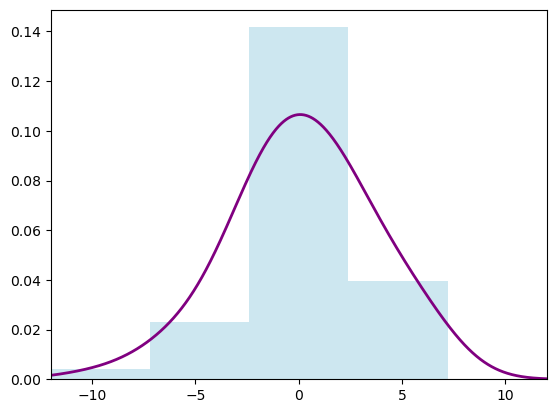

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Tue Jul 14 07:30:35 2026

@author: ashut
"""
# imports/initialisations:
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KernelDensity


num_of_trials = 100
trials = []

for i in range(num_of_trials):
    trials.append(0)

n = 12
p = 0.5

# CORE Logic:
for x in range(num_of_trials):
    for _ in range(n):
        # Generating a uniform random number
        # r between 0 & 1:
        r = random.random()
        
        if (r > 0.5):
            trials[x] = trials[x] + 1
        else:
            trials[x] = trials[x] - 1

# Histogram/Kernel plotting logic
# Density param true changes y axis so that the area of all the bars within
# the histogram add up to 1 (check later for actual formal definition/purpose)
density_param= {'density': True}
bins = np.linspace(-12,12,6) # splits x axis vals into 6 intervals bet. [-12,12]

# Make X_plot 2D so X_plot[:, 0] works and kde.score_samples accepts it
# I think this is also the part where we choose like how many kernels we
# want to have as well:
X_plot = np.linspace(-12, 12,2000).reshape(-1, 1)

# prepping data making it into 2d as that's what sci-kit wants.
trials = np.array(trials)
trials = trials.reshape(-1,1)

# initialise figure & axes:
fig,ax = plt.subplots();

# Plotting histogram, making it semi transparent as we will just display
# the Gaussian KDE over the histogram:
ax.hist(trials,bins=bins,**density_param,color='lightblue',alpha=0.6)


# Gaussian KDE:
kde = KernelDensity(kernel='gaussian',bandwidth=2).fit(trials)
log_dens = kde.score_samples(X_plot)
ax.plot(X_plot[:, 0],np.exp(log_dens),'purple',linewidth=2)

ax.set(xlim=[-12,12])